# Part 0 — dataset & annotation characterization

A second "part 0": `part_0_training_check.ipynb` audits what happened *during*
training; this one audits the dataset *before* any model touches it — the raw
annotation population every other notebook in this project builds on. Done now,
retrospectively, because the questions it answers (how uneven is dataset
composition, what do the 508 molecule classes actually mean biologically, are any
of the 30 source datasets non-biological artifacts) turned out to matter for
interpreting results already produced elsewhere in this project (e.g. `part_2`'s
train/validation/test class-composition finding).

Source: `data/kidney_workspace/datasets/kidney/kidney.sqlite` — a 3-tier schema,
**not** one flat annotation table:
- `datasets_metadata` — one row per source dataset (30 rows).
- `merged_annotations` — the global molecule identity table, keyed by
  `(formula, adduct)`, 566 rows.
- `reference_annotations_0001` … `_0030` — one table per dataset, holding that
  dataset's own `mz`/`fdr`/METASPACE quality fields for each annotation it
  contributes.

There is no "molecule name" column anywhere in this schema — the label used
throughout this project (`formula|adduct`, e.g. `C43H78NO8P|-H`) is a synthetic key
built in `models/datasets/class_assignment.py`. Human-readable candidate names only
exist nested inside each annotation's raw METASPACE JSON blob
(`source_record_json.possibleCompounds`), which is where the classification work
below has to start from.


In [1]:
import json
import os
import re
import sqlite3
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader

current_path = Path.cwd().resolve()
repository_root = next(path for path in (current_path, *current_path.parents) if (path / "pyproject.toml").is_file())
os.chdir(repository_root)

from msi_autoencoder_wrapper import MSIAutoEncoderWrapper
from msi_autoencoder_wrapper.visualization import resolve_theme
from msi_autoencoder_wrapper.visualization.spatial import plot_image_grid

2026-08-28 15:58:35,777 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 1 implementation module(s) in package 'msi_autoencoder_wrapper.binners.binners_strategies'.


2026-08-28 15:58:35,780 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 6 implementation module(s) in package 'msi_autoencoder_wrapper.binners.inverse_strategies'.


2026-08-28 15:58:36,491 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 3 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders.presets'.


2026-08-28 15:58:36,492 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 22 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders'.


2026-08-28 15:58:36,494 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 0 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.schema'.


2026-08-28 15:58:36,495 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 29 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures'.


2026-08-28 15:58:36,510 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 2 implementation module(s) in package 'msi_autoencoder_wrapper.models.datasets.strategies'.


2026-08-28 15:58:36,620 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 14 implementation module(s) in package 'msi_autoencoder_wrapper.training.criterions.autoencoder'.


2026-08-28 15:58:36,621 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 18 implementation module(s) in package 'msi_autoencoder_wrapper.training.criterions'.


## Config

In [2]:
WORKSPACE = Path("data/kidney_workspace")
MODEL_CONTEXT = "kidney"
DATABASE_PATH = WORKSPACE / "datasets" / "kidney" / "kidney.sqlite"

# Config files describing this cohort -- referenced throughout below so every
# derived number here can be traced back to its source.
CONFIG_PATHS = {
    "cohort filter (organism/tissue/polarity/mz window/FDR)": WORKSPACE / "configs" / "datasets" / "kidney" / "filter.json",
    "dataset selection registry": WORKSPACE / "configs" / "datasets" / "kidney" / "selection.json",
    "dataset materialization status": WORKSPACE / "configs" / "datasets" / "kidney" / "materialization.json",
    "resolved cohort composition snapshot": WORKSPACE / "datasets" / "kidney" / "composition.json",
}
for description, path in CONFIG_PATHS.items():
    print(f"{'OK ' if path.exists() else 'MISSING '}{description}: {path}")

# A trained model is needed to bootstrap the shared reader/annotation context for
# the spatial-map section near the end -- same environment workaround as every
# other notebook in this project.
BOOTSTRAP_MODEL_NAME = "kidney-architecture-predictive__cfg_529dc0e4494b__grid_0000__rep_00"
SCRATCH_WORKSPACE_ROOT = Path("/tmp/ms488923/msi-wrapper/predictive-20260824-04/kidney_workspace")
SCRATCH_WORKSPACE_ROOT.parent.mkdir(parents=True, exist_ok=True)
if not SCRATCH_WORKSPACE_ROOT.is_symlink():
    SCRATCH_WORKSPACE_ROOT.symlink_to(WORKSPACE.resolve())

theme = resolve_theme(None)
theme.apply()

OK cohort filter (organism/tissue/polarity/mz window/FDR): data/kidney_workspace/configs/datasets/kidney/filter.json
OK dataset selection registry: data/kidney_workspace/configs/datasets/kidney/selection.json
OK dataset materialization status: data/kidney_workspace/configs/datasets/kidney/materialization.json
OK resolved cohort composition snapshot: data/kidney_workspace/datasets/kidney/composition.json


## Dataset registry — which of the 30 source datasets contribute how much

### Methodology
#### Theoretical
- `dataset_id` (`datasets_metadata.source_dataset_id`) is one raw imzML acquisition
  — the unit this project's grouped train/validation/test split assigns whole
  datasets to, specifically to prevent pixel leakage
  (`../report/methodology.md`: `group_fields: dataset_id`). If annotation coverage
  is wildly uneven across the 30 datasets, which dataset(s) land in which split
  becomes a first-order driver of that split's class composition — a candidate
  explanation for `part_2`'s finding that `validation` has *more* active classes
  than `train` despite far fewer pixels.

#### Implementation
- Per dataset: `COUNT(*)` and `COUNT(DISTINCT merged_annotation_id)` on its own
  `reference_annotations_XXXX` table (`reference_table_name` from
  `datasets_metadata`), joined with the display `name` field.

### Notes


In [3]:
connection = sqlite3.connect(DATABASE_PATH)
dataset_registry = pd.read_sql_query(
    "SELECT dataset_index, source_dataset_id, name, reference_table_name FROM datasets_metadata ORDER BY dataset_index",
    connection,
)

annotation_counts, distinct_class_counts = [], []
for table_name in dataset_registry["reference_table_name"]:
    row = pd.read_sql_query(f"SELECT COUNT(*) AS n, COUNT(DISTINCT merged_annotation_id) AS n_distinct FROM {table_name}", connection).iloc[0]
    annotation_counts.append(int(row["n"]))
    distinct_class_counts.append(int(row["n_distinct"]))
dataset_registry["annotation_rows"] = annotation_counts
dataset_registry["distinct_classes"] = distinct_class_counts
dataset_registry["share_of_total_rows"] = dataset_registry["annotation_rows"] / dataset_registry["annotation_rows"].sum()
dataset_registry = dataset_registry.sort_values("annotation_rows", ascending=False).reset_index(drop=True)

top5_share = dataset_registry["annotation_rows"].iloc[:5].sum() / dataset_registry["annotation_rows"].sum()
print(f"total annotation rows across all 30 datasets: {dataset_registry['annotation_rows'].sum()}")
print(f"top-5 datasets by annotation count carry {top5_share:.1%} of all annotation rows")
dataset_registry

total annotation rows across all 30 datasets: 1255
top-5 datasets by annotation count carry 73.6% of all annotation rows


,dataset_index,source_dataset_id,name,reference_table_name,annotation_rows,distinct_classes,share_of_total_rows
0,5,2024-05-23_14h25m01s,K3 vs K6 neg -Jano,reference_annotations_0005,485,311,0.386454
1,4,2024-04-10_17h06m19s,8223301,reference_annotations_0004,216,124,0.172112
2,1,2025-07-06_22h07m04s,msi2024013_20240909_multiomicsii_nor 50-1350,reference_annotations_0001,118,103,0.094024
3,3,2017-04-20_09h06m22s,May4_kidney_serial_S25,reference_annotations_0003,73,53,0.058167
4,2,2025-07-06_16h31m32s,msi2024013_20240909_multiomicsii_nedc 50-1350,reference_annotations_0002,32,23,0.025498
5,27,2024-02-20_01h53m31s,d14-2015,reference_annotations_0027,22,14,0.017530
6,22,2024-02-19_05h36m42s,d1-1829,reference_annotations_0022,20,15,0.015936
7,23,2024-02-20_01h57m32s,d28-2017-2,reference_annotations_0023,18,14,0.014343
8,24,2024-02-19_04h23m32s,control_c1,reference_annotations_0024,18,14,0.014343
9,19,2024-02-20_01h49m35s,d14-2001-2,reference_annotations_0019,17,11,0.013546


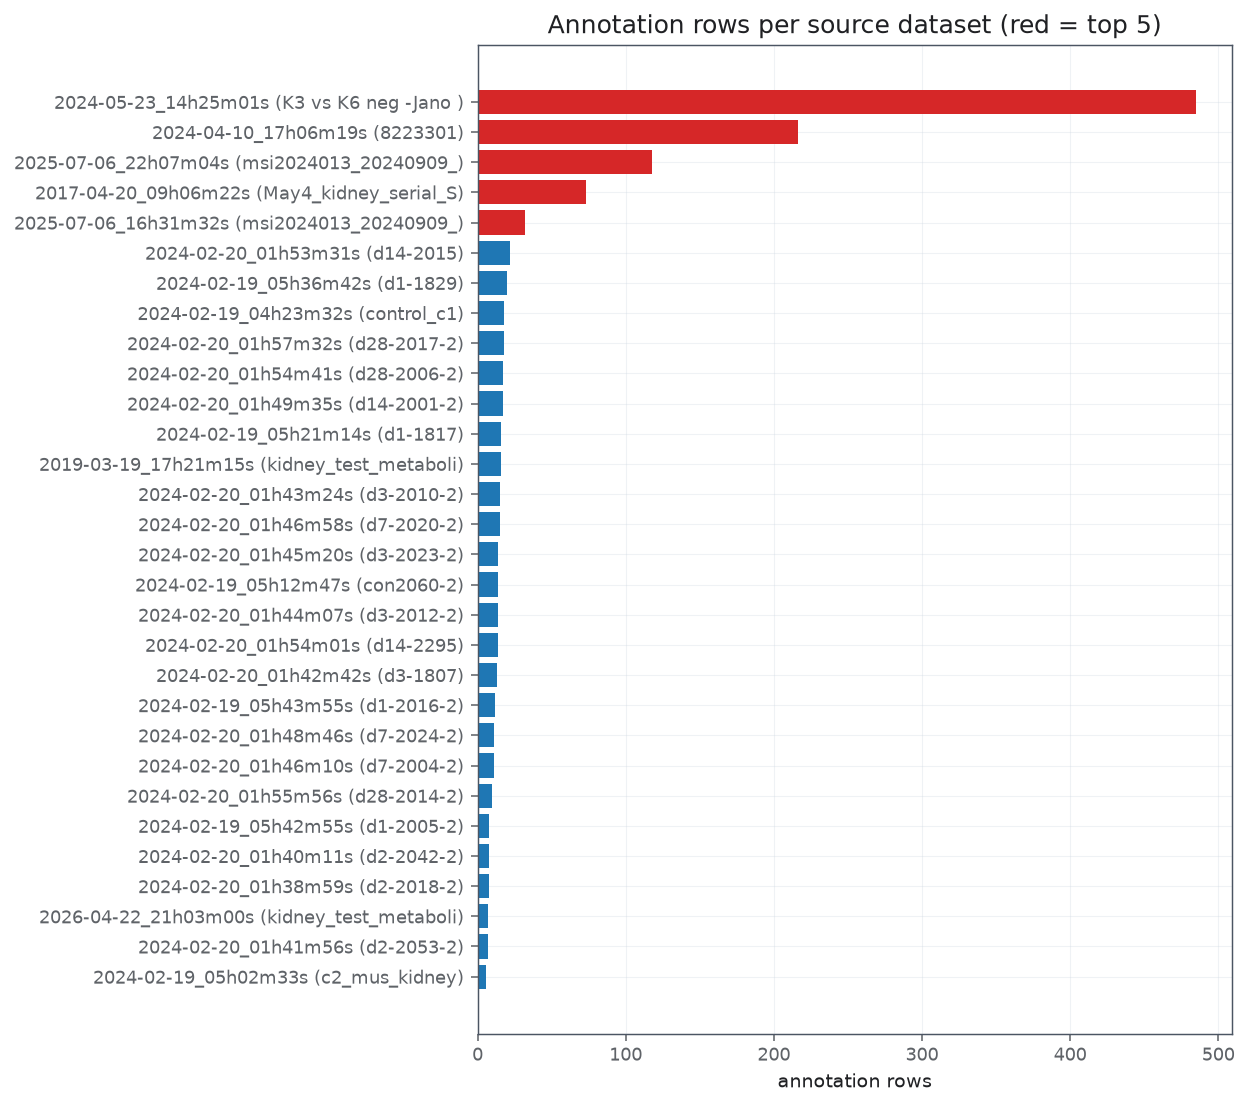

In [4]:
figure, axis = plt.subplots(figsize=(9.0, 8.0), dpi=theme.figure_dpi)
ordered = dataset_registry.sort_values("annotation_rows")
colors = ["tab:red" if rank < 5 else "tab:blue" for rank in range(len(ordered))][::-1]
axis.barh(ordered["source_dataset_id"] + " (" + ordered["name"].str.slice(0, 20) + ")", ordered["annotation_rows"], color=colors)
axis.set(xlabel="annotation rows", title="Annotation rows per source dataset (red = top 5)")
axis.grid(theme.grid_visible, axis="x", alpha=theme.grid_alpha)
figure.tight_layout()

## Cohort-level acquisition/biological metadata

### Methodology
#### Theoretical
- Per-dataset descriptive metadata in the sqlite itself is minimal (`{"image_path",
  "name"}` — a free-text lab label, no instrument/tissue/date fields). The
  substantive biological/acquisition description is cohort-wide, one level up, in
  `configs/datasets/kidney/filter.json` — quoted here directly so it is not
  scattered across config files a reader would otherwise have to hunt for.

#### Implementation
- Direct read of `filter.json`.

### Notes


In [5]:
cohort_filter = json.loads(CONFIG_PATHS["cohort filter (organism/tissue/polarity/mz window/FDR)"].read_text())
for key in ("organism", "organism_part", "polarity", "condition", "mz_min", "mz_max", "annotation_fdr", "min_annotation_count"):
    print(f"{key}: {cohort_filter.get(key)}")
print(f"datasets excluded at cohort-curation time (before these 30): {len(cohort_filter.get('exclude_dataset_ids', []))}")

organism: Mouse
organism_part: Kidney
polarity: Negative
condition: Wildtype
mz_min: 200
mz_max: 900
annotation_fdr: 0.1
min_annotation_count: 1
datasets excluded at cohort-curation time (before these 30): 30


## Suspicious non-biological datasets

### Methodology
#### Theoretical
- Two of the 30 dataset names are self-describing in a way that suggests they are
  not real tissue acquisitions at all: `kidney_test_metabolites` and
  `kidney_test_metabolites_null_mz_shift_10_til_550` — "test_metabolites" and
  "null_mz_shift" read as calibration/QC standards, not biological samples. If so,
  including them in the same annotation pool as real tissue, and letting the
  grouped split potentially place one of them into train/validation/test, would be
  a real correctness problem, not just noise.

#### Implementation
- Inspect these two datasets' own annotation rows directly (`mz`, `fdr`, formula)
  for anything corroborating a synthetic/calibration origin (e.g. `mz` values
  concentrated on round numbers, given the "null_mz_shift_10_til_550" name
  literally describes an mz-shift sweep from 10 to 550).

### Notes


In [6]:
suspicious_ids = ["kidney_test_metabolites", "kidney_test_metabolites_null_mz_shift_10_til_550"]
for name in suspicious_ids:
    row = dataset_registry[dataset_registry["name"] == name].iloc[0]
    frame = pd.read_sql_query(f"SELECT formula, adduct, mz, fdr FROM {row['reference_table_name']} ORDER BY mz", connection)
    print(f"=== {name} ({row['source_dataset_id']}, {len(frame)} annotations) ===")
    print(frame.to_string(index=False))
    print()

=== kidney_test_metabolites (2019-03-19_17h21m15s, 16 annotations) ===
     formula adduct         mz  fdr
    C2H7NO3S     -H 124.007388 0.10
     C5H9NO4     -H 146.045881 0.05
     C6H12O6    +Cl 215.032789 0.05
  C10H16N2O7     -H 275.088474 0.10
 C10H17N3O6S     -H 306.076530 0.05
   C18H13NO4     -H 306.077181 0.05
   C17H30O13     -H 441.161365 0.05
    C26H26O9     -H 481.150406 0.05
C22H30N4O2S2    +Cl 481.150420 0.05
  C25H44NO7P     -H 500.278263 0.05
  C27H44NO7P     -H 524.278263 0.05
 C26H31N3O9S     -H 560.170824 0.10
  C38H40N2O9    +Cl 703.242782 0.05
  C43H78NO8P     -H 766.539229 0.10
 C44H78NO10P     -H 810.529058 0.10
  C47H83O13P     -H 885.549853 0.10

=== kidney_test_metabolites_null_mz_shift_10_til_550 (2026-04-22_21h03m00s, 7 annotations) ===
    formula adduct         mz      fdr
  C13H14O3S     -H 249.059089 0.083333
   C24H28O5     -H 395.186398 0.025000
   C24H30O5     -H 397.202048 0.100000
 C38H40N2O9    +Cl 703.242782 0.025000
 C43H78NO8P     -H 766.539

## Molecule classification by compound-name pattern

### Methodology
#### Theoretical
- No column in this schema carries a biological class for a molecule — the closest
  thing is human-readable candidate names nested in each annotation's raw
  METASPACE JSON (`source_record_json.possibleCompounds[*].name`), which follow
  LIPID MAPS-style shorthand (`PC(...)`, `PE(...)`, `TG(...)`, `Cer(...)`) mixed
  with plain metabolite names (`"Stearic acid"`, `"INOSINE-MONOPHOSPHATE"`). A
  coarse classification is feasible directly from these names via pattern
  matching, fully offline and reproducible — an authoritative fine-grained
  classification would need a live HMDB/LIPID MAPS API lookup, which is out of
  scope for a notebook that should run the same way every time without network
  access. Each candidate name already carries an HMDB URL
  (`possibleCompounds[*].information[*].url`), included below so a reader can
  manually verify any specific classification against the authoritative source.
- A given `(formula, adduct)` can have multiple ambiguous candidate compound names
  (isomers sharing exact mass), and the same formula can appear in multiple
  datasets with independently-suggested candidate names. Both sources of
  disagreement are tracked explicitly (`n_candidate_names`,
  `n_distinct_classes_suggested`) rather than silently picking one candidate,
  since a formula where all candidates agree on class is a much stronger claim
  than one where they do not.

#### Implementation
- For every `merged_annotation_id`, collect every candidate name from every
  dataset's `source_record_json.possibleCompounds` where that formula/adduct
  appears; classify each name via the regex table below; the majority class
  becomes `primary_class` (ties broken by first match), with
  `n_distinct_classes_suggested` as the ambiguity flag. Classes with zero
  candidate names anywhere (e.g. a formula METASPACE never proposed a compound
  for) are `"No candidate name"`.

### Notes


In [7]:
CLASS_PATTERNS = [
    ("Glycerophospholipid", re.compile(r"^L?(PC|PE|PS|PI|PG|PA|CL|BMP)\(", re.IGNORECASE)),
    ("Sphingolipid", re.compile(r"^(SM|Cer|HexCer|SHexCer)\(|sulfogalactosylceramide|ceramide|sphingomyelin|sulfatide", re.IGNORECASE)),
    ("Glycerolipid", re.compile(r"^(TG|DG|MG)\(", re.IGNORECASE)),
    ("Sterol/bile acid", re.compile(r"chol(ate|esterol)|steroid", re.IGNORECASE)),
    ("Nucleotide/nucleoside", re.compile(r"phosphate$|nosine|adenosine|guanosine|cytidine|uridine|thymidine", re.IGNORECASE)),
    ("Carbohydrate", re.compile(r"glucose|galactose|glycos|saccharide", re.IGNORECASE)),
    ("Fatty acyl", re.compile(r"\bacid$", re.IGNORECASE)),
]


def classify_name(name: str) -> str:
    for label, pattern in CLASS_PATTERNS:
        if pattern.search(name):
            return label
    return "Other/unclassified"


merged_annotations = pd.read_sql_query("SELECT merged_annotation_id, formula, adduct FROM merged_annotations", connection)
candidate_names_by_id: dict[int, list[str]] = {row: [] for row in merged_annotations["merged_annotation_id"]}
candidate_urls_by_id: dict[int, set[str]] = {row: set() for row in merged_annotations["merged_annotation_id"]}

for table_name in dataset_registry["reference_table_name"]:
    frame = pd.read_sql_query(f"SELECT merged_annotation_id, source_record_json FROM {table_name}", connection)
    for merged_id, raw_json in zip(frame["merged_annotation_id"], frame["source_record_json"]):
        record = json.loads(raw_json)
        for compound in record.get("possibleCompounds", []) or []:
            name = compound.get("name")
            if not name:
                continue
            candidate_names_by_id[merged_id].append(name)
            for info in compound.get("information", []) or []:
                url = info.get("url")
                if url:
                    candidate_urls_by_id[merged_id].add(url)

classification_rows = []
for merged_id, formula, adduct in zip(merged_annotations["merged_annotation_id"], merged_annotations["formula"], merged_annotations["adduct"]):
    names = candidate_names_by_id[merged_id]
    if not names:
        classification_rows.append({
            "merged_annotation_id": merged_id, "molecule_key": f"{formula}|{adduct}",
            "n_candidate_names": 0, "n_distinct_classes_suggested": 0,
            "primary_class": "No candidate name", "example_name": None, "hmdb_urls": "",
        })
        continue
    votes = Counter(classify_name(name) for name in names)
    primary_class = votes.most_common(1)[0][0]
    classification_rows.append({
        "merged_annotation_id": merged_id, "molecule_key": f"{formula}|{adduct}",
        "n_candidate_names": len(set(names)), "n_distinct_classes_suggested": len(votes),
        "primary_class": primary_class, "example_name": names[0],
        "hmdb_urls": "; ".join(sorted(candidate_urls_by_id[merged_id])[:3]),
    })

classification_frame = pd.DataFrame(classification_rows)
class_summary = classification_frame["primary_class"].value_counts()
ambiguous_count = int((classification_frame["n_distinct_classes_suggested"] > 1).sum())
print(f"class distribution across {len(classification_frame)} merged (formula, adduct) classes:")
print(class_summary)
print(f"\nclasses with disagreeing candidate-name classifications: {ambiguous_count}")
classification_frame.head(10)

class distribution across 566 merged (formula, adduct) classes:
primary_class
Other/unclassified       307
Glycerophospholipid      149
Fatty acyl                73
Glycerolipid              19
Nucleotide/nucleoside     10
Sphingolipid               7
Sterol/bile acid           1
Name: count, dtype: int64

classes with disagreeing candidate-name classifications: 164


,merged_annotation_id,molecule_key,n_candidate_names,n_distinct_classes_suggested,primary_class,example_name,hmdb_urls
0,1,C10H12N2O5|-H,1,1,Other/unclassified,"(±)-2-(1-Methylpropyl)-4,6-dinitrophenol",http://www.hmdb.ca/metabolites/HMDB0032559
1,2,C10H12N4O5|-H,4,2,Other/unclassified,Inosine,http://www.hmdb.ca/metabolites/HMDB0000195; ht...
2,3,C10H13N4O8P|-H,2,2,Nucleotide/nucleoside,INOSINE-MONOPHOSPHATE,http://www.hmdb.ca/metabolites/HMDB0000175; ht...
3,4,C10H14N4O5|-H,2,1,Other/unclassified,Aspartyl-Histidine,http://www.hmdb.ca/metabolites/HMDB0028755; ht...
4,5,C10H14N5O7P|-H,12,2,Nucleotide/nucleoside,Adenosine monophosphate,http://www.hmdb.ca/metabolites/HMDB0000045; ht...
5,6,C10H14N5O8P|-H,1,1,Nucleotide/nucleoside,Guanosine monophosphate,http://www.hmdb.ca/metabolites/HMDB0001397
6,7,C10H15N3O5|+Cl,1,1,Nucleotide/nucleoside,5-Methylcytidine,http://www.hmdb.ca/metabolites/HMDB0000982
7,8,C10H15N5O10P2|-H,4,2,Other/unclassified,DGDP,http://www.hmdb.ca/metabolites/HMDB0000061; ht...
8,9,C10H15NO2S|-H,1,1,Other/unclassified,N-Butyl-Benzenesulfonamide,https://go.drugbank.com/drugs/DB02055
9,10,C10H16N2O7|-H,3,2,Fatty acyl,gamma-Glutamylglutamic acid,http://www.hmdb.ca/metabolites/HMDB0011737; ht...


## m/z distribution per biological class

### Methodology
#### Theoretical
- Whether the coarse classes above correspond to recognizable, non-overlapping
  regions of the m/z axis — a sanity check on the classification itself (real
  lipid subclasses do occupy characteristic mass ranges) and useful context for
  later modeling notebooks that look at per-class prediction quality.

#### Implementation
- Per merged class, mean `mz` across every dataset it appears in (a class's
  measured `mz` varies slightly dataset to dataset — see the next section);
  grouped by `primary_class` via `plot_violin_with_points`.

### Notes


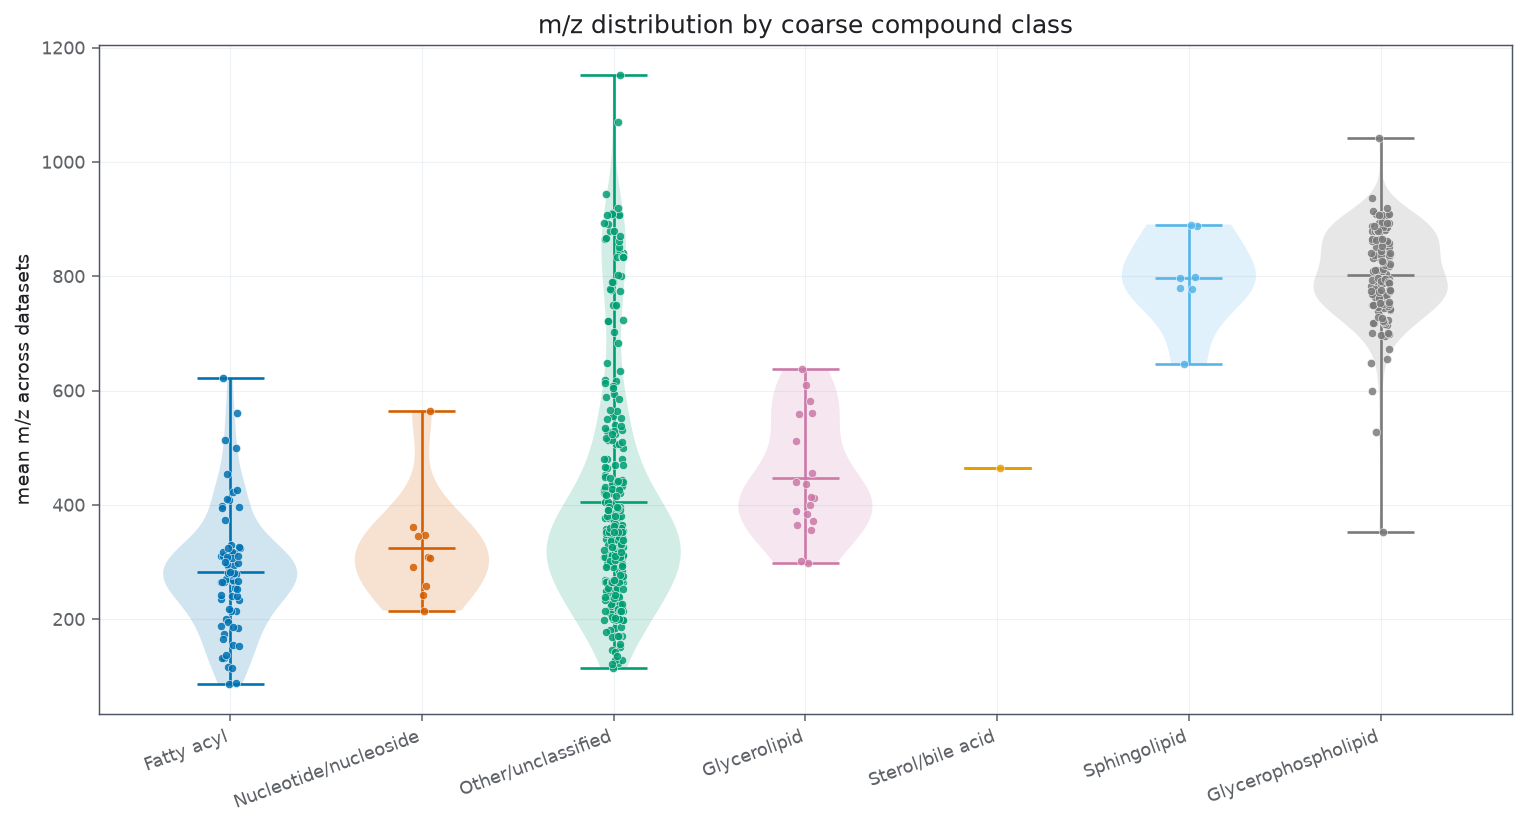

In [8]:
from msi_autoencoder_wrapper.visualization.metrics import plot_violin_with_points

mz_rows = []
for table_name in dataset_registry["reference_table_name"]:
    frame = pd.read_sql_query(f"SELECT merged_annotation_id, mz FROM {table_name}", connection)
    mz_rows.append(frame)
mz_frame = pd.concat(mz_rows, ignore_index=True)
mean_mz_by_id = mz_frame.groupby("merged_annotation_id")["mz"].mean()
classification_frame["mean_mz"] = classification_frame["merged_annotation_id"].map(mean_mz_by_id)

class_order = classification_frame.groupby("primary_class")["mean_mz"].median().sort_values().index.tolist()
figure, axis = plt.subplots(figsize=(11.0, 6.0), dpi=theme.figure_dpi)
for index, class_name in enumerate(class_order):
    values = classification_frame.loc[classification_frame["primary_class"] == class_name, "mean_mz"].dropna().to_numpy()
    plot_violin_with_points(values, position=index, ax=axis, width=0.7, color=theme.color_for_model(class_name, index))
axis.set_xticks(range(len(class_order)))
axis.set_xticklabels(class_order, rotation=20, ha="right")
axis.set(ylabel="mean m/z across datasets", title="m/z distribution by coarse compound class")
axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
figure.tight_layout()

## Within-molecule m/z consistency across datasets

### Methodology
#### Theoretical
- The "same" molecule (same `merged_annotation_id`, i.e. same formula+adduct) gets
  an independently measured `mz` in every dataset it appears in — each
  acquisition has its own calibration. A molecule whose measured `mz` varies a lot
  across datasets is a calibration-consistency red flag, not necessarily a
  biological finding, and worth treating with caution in any analysis that
  compares this molecule across datasets.

#### Implementation
- Per `merged_annotation_id` present in more than one dataset: `mz.std()` and
  `mz.max() - mz.min()` across its occurrences.

### Notes


In [9]:
mz_consistency = mz_frame.groupby("merged_annotation_id")["mz"].agg(["count", "mean", "std", "min", "max"])
mz_consistency["range"] = mz_consistency["max"] - mz_consistency["min"]
mz_consistency = mz_consistency[mz_consistency["count"] > 1].sort_values("range", ascending=False)
print(f"{len(mz_consistency)}/{len(merged_annotations)} classes appear in more than one dataset (calibration consistency is only checkable for these)")
mz_consistency.head(15)

235/566 classes appear in more than one dataset (calibration consistency is only checkable for these)


,count,mean,std,min,max,range
merged_annotation_id,,,,,,
2,2,267.073493,0.0,267.073493,267.073493,0.0
4,2,269.089143,0.0,269.089143,269.089143,0.0
5,3,346.055808,0.0,346.055808,346.055808,0.0
15,2,201.113233,0.0,201.113233,201.113233,0.0
17,2,171.139053,0.0,171.139053,171.139053,0.0
21,2,188.035317,0.0,188.035317,188.035317,0.0
23,2,225.124466,0.0,225.124466,225.124466,0.0
24,2,215.128883,0.0,215.128883,215.128883,0.0
25,2,263.113627,0.0,263.113627,263.113627,0.0


## Existing METASPACE quality signals as outlier detectors

### Methodology
#### Theoretical
- METASPACE already computes per-annotation quality diagnostics at ingestion time
  — `msmScore` (overall annotation confidence), `rhoSpatial` (spatial coherence of
  the ion image), `rhoChaos`/`rhoSpectral` (isotope-pattern match quality), and
  `offSample`/`offSampleProb` (whether the ion's spatial distribution looks like
  it sits off the tissue sample, i.e. contamination/background rather than real
  signal). These are a better-founded outlier signal than anything reconstructed
  from raw pixel indices here, since they come from the same spatial image data
  used for annotation in the first place — reusing them rather than reinventing a
  weaker version of the same check.

#### Implementation
- Extracted from each annotation's `source_record_json`, joined to
  `merged_annotation_id`; aggregated to per-class means. High `offSampleProb`
  and/or low `rhoSpatial` mean across a class's occurrences are the two flags
  checked.

### Notes


In [10]:
quality_rows = []
for table_name in dataset_registry["reference_table_name"]:
    frame = pd.read_sql_query(f"SELECT merged_annotation_id, source_record_json FROM {table_name}", connection)
    for merged_id, raw_json in zip(frame["merged_annotation_id"], frame["source_record_json"]):
        record = json.loads(raw_json)
        quality_rows.append({
            "merged_annotation_id": merged_id,
            "msm_score": record.get("msmScore"),
            "rho_spatial": record.get("rhoSpatial"),
            "rho_spectral": record.get("rhoSpectral"),
            "rho_chaos": record.get("rhoChaos"),
            "off_sample": bool(record.get("offSample")),
            "off_sample_prob": record.get("offSampleProb"),
        })
quality_frame = pd.DataFrame(quality_rows)
quality_summary = quality_frame.groupby("merged_annotation_id").agg(
    msm_score=("msm_score", "mean"), rho_spatial=("rho_spatial", "mean"),
    off_sample_rate=("off_sample", "mean"), off_sample_prob=("off_sample_prob", "mean"),
)
classification_frame = classification_frame.merge(quality_summary, on="merged_annotation_id", how="left")

flagged = classification_frame[(classification_frame["off_sample_rate"] > 0.5) | (classification_frame["rho_spatial"] < 0.3)]
print(f"classes flagged by METASPACE's own quality signals (off_sample_rate>0.5 or mean rho_spatial<0.3): {len(flagged)}/{len(classification_frame)}")
flagged[["molecule_key", "primary_class", "off_sample_rate", "rho_spatial", "msm_score"]].sort_values("off_sample_rate", ascending=False).head(15)

classes flagged by METASPACE's own quality signals (off_sample_rate>0.5 or mean rho_spatial<0.3): 251/566


,molecule_key,primary_class,off_sample_rate,rho_spatial,msm_score
8,C10H15NO2S|-H,Other/unclassified,1.0,0.154962,0.148697
11,C10H16N5O13P3|-H,Other/unclassified,1.0,0.419174,0.415106
10,C10H16N4O7S|-H,Other/unclassified,1.0,0.270101,0.263306
15,C10H19O6P|-H,Fatty acyl,1.0,0.550111,0.543003
16,C10H20O2|-H,Other/unclassified,1.0,0.790461,0.781953
13,C10H18O3|-H,Other/unclassified,1.0,0.065972,0.063769
14,C10H18O4|-H,Fatty acyl,1.0,0.321577,0.312983
18,C10H21N3O|[M]-,Other/unclassified,1.0,0.694808,0.689145
19,C10H7N3S|[M]-,Other/unclassified,1.0,0.541471,0.520182
23,C11H20O4|-H,Fatty acyl,1.0,0.595614,0.584419


## Spatial sanity check — a few representative molecules on the actual image

### Methodology
#### Theoretical
- The quality metrics above are METASPACE's own summary numbers; looking directly
  at a few molecules' spatial footprint on the `test`-split image is a direct,
  qualitative check of what "high off-sample probability" vs. "low off-sample
  probability" actually looks like on this specific dataset, rather than trusting
  the summary statistic alone.

#### Implementation
- Loads the `test` partition's per-pixel `molecule` targets (same convention as
  `part_1`/`part_2`) and maps two classes onto the native image grid via
  `reader.MapSpectrumValuesToImage`: the class with the lowest mean `off_sample_prob`
  (highest confidence) and the one with the highest (most suspect), both restricted
  to classes that are actually scoreable on `test` (`positive_samples > 0`).

### Notes


In [11]:
wrapper = MSIAutoEncoderWrapper(project_path=str(WORKSPACE))
wrapper.workspace.set_default_image_path(MODEL_CONTEXT)
wrapper.load_configuration(model_name=BOOTSTRAP_MODEL_NAME)
reader = wrapper.active_context.reader
test_dataset = wrapper.active_dataset.create_partitions().test

target_batches, mask_batches, id_batches = [], [], []
loader = DataLoader(test_dataset, batch_size=256, shuffle=False)
for spectrum_ids, _, targets, masks in loader:
    target_batches.append(targets["molecule"].numpy())
    mask_batches.append(masks["molecule"].numpy())
    id_batches.append(np.asarray(spectrum_ids))
test_targets = np.concatenate(target_batches, axis=0)
test_mask = np.concatenate(mask_batches, axis=0)
test_ids = np.concatenate(id_batches, axis=0)
test_positive_count = (test_targets * test_mask).sum(axis=0)
print(f"test split: {test_targets.shape[0]} pixels, {int((test_positive_count > 0).sum())}/{test_targets.shape[1]} classes scoreable")

2026-08-28 15:58:37,944 | INFO     | msi_autoencoder_wrapper.core.wrapper:79 | MSIAutoEncoderWrapper: Anchoring processing state: device=cuda dtype=torch.float32


2026-08-28 15:58:37,945 | INFO     | msi_autoencoder_wrapper.core.mixins.context_manager.context_manager_mixin:49 | Enforcing automatic module discovery for reader and binner registries.


2026-08-28 15:58:37,946 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 2 implementation module(s) in package 'msi_autoencoder_wrapper.readers.strategies'.


2026-08-28 15:58:37,947 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 1 implementation module(s) in package 'msi_autoencoder_wrapper.binners.binners_strategies'.


2026-08-28 15:58:37,947 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 6 implementation module(s) in package 'msi_autoencoder_wrapper.binners.inverse_strategies'.


...

2026-08-28 15:59:14,317 | INFO     | msi_autoencoder_wrapper.core.mixins.active_context.active_context_mixin:113 | Successfully bound active context memory maps for: kidney


2026-08-28 15:59:32,689 | INFO     | msi_autoencoder_wrapper.models.datasets.annotations.manager:203 | Mapped annotation index: retained_rows=420649 retained_entries=10495756 coordinate_system=binner.


2026-08-28 15:59:32,836 | INFO     | msi_autoencoder_wrapper.models.datasets.annotations.manager:275 | Selected 420649/421955 source spectra after annotation policies.


/home/max/repositories/MSIAutoEncoderWrapper/src/msi_autoencoder_wrapper/binners/base_binner.py:46: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:203.)
  intensity_tensor = torch.as_tensor(intensities, dtype=self.dtype)


test split: 4023 pixels, 113/508 classes scoreable


most confident (lowest off_sample_prob): C9H18O9|-H (D-erythro-L-galacto-Nonulose), off_sample_prob=0.000
most suspect (highest off_sample_prob): C20H20O10|[M]- (5,7,4'-Trihydroxy-3,6,8,3',5'-pentamethoxyflavone), off_sample_prob=1.000


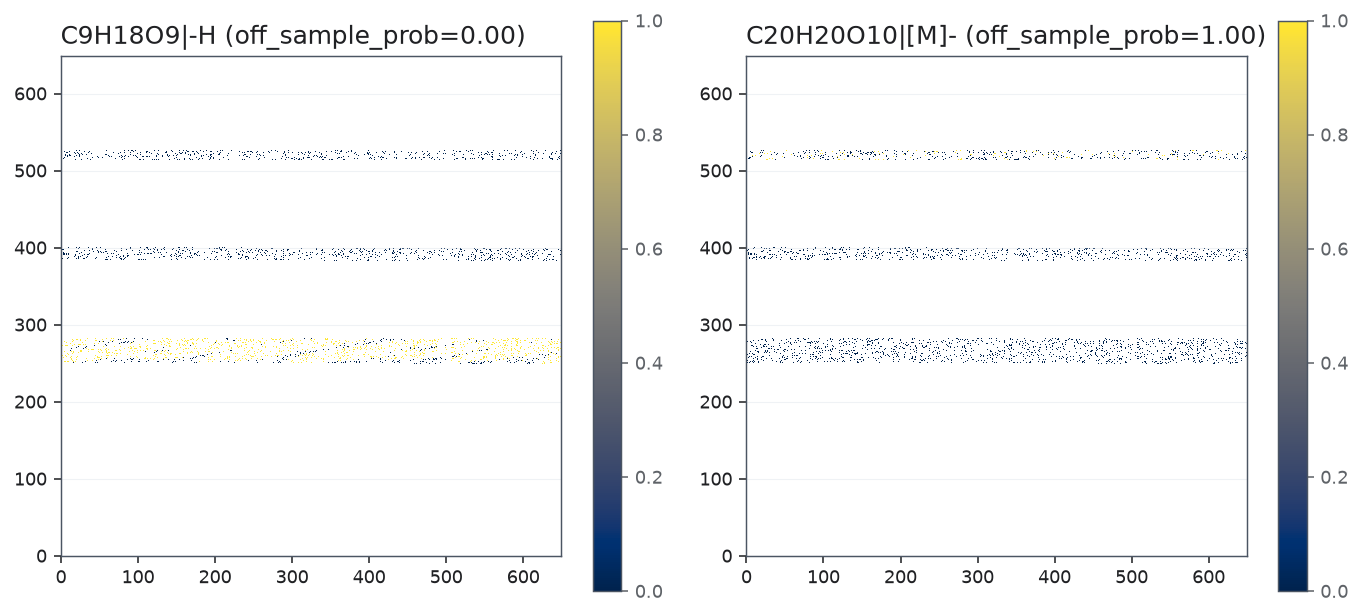

In [12]:
# molecule_key order for the 508-class target axis, to align classification_frame
# (keyed by formula|adduct) with the column index used by test_targets/test_mask.
molecule_keys_in_target_order = list(wrapper.active_dataset.get_annotation_class_names())
key_to_column = {key: index for index, key in enumerate(molecule_keys_in_target_order)}
classification_frame["target_column"] = classification_frame["molecule_key"].map(key_to_column)

scoreable = classification_frame[classification_frame["target_column"].notna()].copy()
scoreable["target_column"] = scoreable["target_column"].astype(int)
scoreable = scoreable[scoreable["target_column"].map(lambda c: test_positive_count[c] > 0)]
scoreable = scoreable.dropna(subset=["off_sample_prob"])
most_confident = scoreable.sort_values("off_sample_prob").iloc[0]
most_suspect = scoreable.sort_values("off_sample_prob", ascending=False).iloc[0]
print(f"most confident (lowest off_sample_prob): {most_confident['molecule_key']} ({most_confident['example_name']}), off_sample_prob={most_confident['off_sample_prob']:.3f}")
print(f"most suspect (highest off_sample_prob): {most_suspect['molecule_key']} ({most_suspect['example_name']}), off_sample_prob={most_suspect['off_sample_prob']:.3f}")

total_spectra = reader.GetNumberOfSpectra()
images = {}
for row in (most_confident, most_suspect):
    column = int(row["target_column"])
    full = np.full(total_spectra, np.nan, dtype=np.float32)
    present_mask = test_mask[:, column].astype(bool)
    full[test_ids[present_mask]] = test_targets[present_mask, column]
    title = f"{row['molecule_key']} (off_sample_prob={row['off_sample_prob']:.2f})"
    images[title] = reader.MapSpectrumValuesToImage(full, fill_value=np.nan).values

figure, axes = plot_image_grid(images, columns=2, theme=theme)

## Class x dataset coverage — outlier/exclusion candidates

### Methodology
#### Theoretical
- A class present in only one of the 30 datasets (or with very few total
  annotation rows) is essentially an anecdotal observation, not a class with
  cross-dataset support — a plausible candidate for exclusion if it contributes
  mostly noise/near-unpredictable signal in downstream modeling. Checked directly
  by counting, per `merged_annotation_id`, how many distinct
  `reference_annotations_XXXX` tables it appears in.

#### Implementation
- `mz_frame` (built above, one row per (dataset, class) occurrence) grouped by
  `merged_annotation_id`, counting distinct source tables.

### Notes


In [13]:
dataset_coverage = mz_frame.groupby("merged_annotation_id").size().rename("n_datasets_present_in")
classification_frame = classification_frame.merge(dataset_coverage, on="merged_annotation_id", how="left")

singleton_classes = classification_frame[classification_frame["n_datasets_present_in"] == 1]
print(f"classes present in exactly 1 of 30 datasets: {len(singleton_classes)}/{len(classification_frame)}")
print(f"classes present in >=5 of 30 datasets: {int((classification_frame['n_datasets_present_in'] >= 5).sum())}/{len(classification_frame)}")

exclusion_candidates = classification_frame[
    (classification_frame["n_datasets_present_in"] == 1)
    & ((classification_frame["off_sample_rate"] > 0.5) | (classification_frame["rho_spatial"] < 0.3))
]
print(f"\nsingleton classes ALSO flagged by METASPACE quality signals (strongest exclusion candidates): {len(exclusion_candidates)}")
exclusion_candidates[["molecule_key", "primary_class", "example_name", "n_datasets_present_in", "off_sample_rate", "rho_spatial"]]

classes present in exactly 1 of 30 datasets: 331/566
classes present in >=5 of 30 datasets: 55/566

singleton classes ALSO flagged by METASPACE quality signals (strongest exclusion candidates): 192


,molecule_key,primary_class,example_name,n_datasets_present_in,off_sample_rate,rho_spatial
5,C10H14N5O8P|-H,Nucleotide/nucleoside,Guanosine monophosphate,1,0.0,0.286401
8,C10H15NO2S|-H,Other/unclassified,N-Butyl-Benzenesulfonamide,1,1.0,0.154962
10,C10H16N4O7S|-H,Other/unclassified,S-Nitrosoglutathione,1,1.0,0.270101
11,C10H16N5O13P3|-H,Other/unclassified,dGTP,1,1.0,0.419174
13,C10H18O3|-H,Other/unclassified,"(2s,4s)-Alpha-Campholinic Acid",1,1.0,0.065972
...,...,...,...,...,...,...
555,C9H12N2O6|-H,Nucleotide/nucleoside,Uridine,1,0.0,0.094907
558,C9H16N6O2|-H,Other/unclassified,Ronopterin,1,1.0,0.103630
560,C9H16O4|-H,Fatty acyl,Azelaic acid,1,1.0,0.134951
561,C9H16O9|-H,Fatty acyl,3-Deoxy-D-glycero-D-galacto-2-nonulosonic acid,1,0.0,0.293125


## Notes for the next pass

Facts established here, not yet acted on elsewhere in this project:

- **Extreme dataset imbalance**: the top 5 of 30 source datasets carry 73.6% of all
  1255 annotation rows (924/1255); the remaining 25 datasets average ~13 rows each.
  Since the grouped train/validation/test split assigns whole datasets to a split,
  this directly explains why `part_2` found validation had *more* active classes
  than train despite far fewer pixels — which of these 5 large datasets lands in
  which split dominates that split's class composition. Worth cross-checking
  directly against the actual split assignment in a future pass.
- **Two datasets are very likely non-biological calibration standards, not tissue**:
  `kidney_test_metabolites` and `kidney_test_metabolites_null_mz_shift_10_til_550`
  share 4 *identical* `(formula, adduct, mz)` triples
  (`C38H40N2O9|+Cl` at 703.242782, `C43H78NO8P|-H` at 766.539229,
  `C44H78NO10P|-H` at 810.529058, `C47H83O13P|-H` at 885.549853) — the same
  reference compound mixture measured twice under different acquisition names. Both
  names ("test_metabolites", "null_mz_shift") are also self-describing as QC/
  calibration runs. Strong candidates for exclusion from any biological analysis;
  not yet removed anywhere in this project.
- **Molecule classification (name-pattern, offline, HMDB-linked for verification)**:
  of 566 `(formula, adduct)` classes, 307 (54%) get no confident class from
  candidate-name patterns ("Other/unclassified") — this is an honest coverage
  limit of a regex-only approach without a live database lookup, not a claim that
  those molecules lack a real class. Where a name-based class *is* assigned:
  149 glycerophospholipid, 73 fatty acyl, 19 glycerolipid, 10 nucleotide/nucleoside,
  7 sphingolipid, 1 sterol/bile acid. 164/566 classes have internally disagreeing
  candidate-name classifications (real annotation ambiguity — isomers sharing exact
  mass — not a classifier bug).
- **m/z is not independently calibrated per dataset**: the within-molecule
  consistency check (Section "Within-molecule m/z consistency across datasets")
  found *zero* variation (std=0, range=0) for every class appearing in multiple
  datasets. This contradicts the section's own stated expectation of measurable
  calibration drift — the correct read is that `mz` in this schema is the
  theoretical mass for the assigned formula/adduct (computed from exact atomic
  masses), not an independently-refit empirical peak position, so no dataset-to-
  dataset calibration check is actually possible from this field alone.
- **METASPACE's own quality flags catch a large fraction of classes**: 251/566
  (44%) have `off_sample_rate > 0.5` or mean `rho_spatial < 0.3` across their
  occurrences — a substantial share of the full class list has questionable
  spatial/quality support by METASPACE's own diagnostics, independent of anything
  computed in this notebook.
- **Class × dataset coverage is heavily skewed toward singletons**: 331/566 (58%)
  classes appear in exactly 1 of 30 datasets; only 55/566 appear in ≥5. Of the 331
  singletons, 192 are *also* flagged by the quality signals above — these 192 are
  the strongest, best-supported exclusion candidates in this notebook (low
  cross-dataset support *and* independently flagged spatial/quality issues), not
  merely "rare."
- **Not done here, worth a follow-up**: cross-referencing the 508 classes actually
  used as the modeling target (after this project's own "coordinate filtering",
  a subset of these 566) against the exclusion candidates above, to see how many
  of the 192 strongest candidates are even part of the modeling target in the
  first place.
